In [ ]:
# Data Exploration
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

# Machine Learning
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, auc

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer, Activation
from tensorflow.keras.metrics import AUC
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator, array_to_img, load_img
from tensorflow.keras.regularizers import l2, l1

# Additional
from dask import bag, diagnostics
from google.colab import drive
from keras.utils import plot_model
from keras import backend
from mlxtend.plotting import plot_confusion_matrix
from keras import backend as K

In [ ]:
def create_charts(cnn, cnn_model):
    """
    plot1: train & validatoin loss curves
    plot2: train & validatoin accuracy curves
    Plot3: confusion matrix
    Plot4: train & validation ROC curve and AUC score
    Summary Statistics

    """

    ## Define train & validation loss
    train_loss = cnn_model.history['loss']
    val_loss = cnn_model.history['val_loss']

    ## Define train & validation accuracy
    train_auc = cnn_model.history['accuracy']
    val_auc = cnn_model.history['val_accuracy']

    ## Define y_pred & y_true
    y_true = test_generator.classes
    Y_pred = cnn.predict_generator(test_generator, steps = len(test_generator))
    y_pred = (Y_pred > 0.5).T[0]
    y_pred_prob = Y_pred.T[0]

    ## PLOT ##
    fig = plt.figure(figsize=(13, 10))

    ## PLOT 1: TRAIN VS. VALIDATION LOSS
    plt.subplot(2,2,1)
    plt.title("Training vs. Validation Loss")
    plt.plot(train_loss, label='training loss')
    plt.plot(val_loss, label='validation loss')
    plt.xlabel("Number of Epochs", size=14)
    plt.legend()

    ## PLOT 2: TRAIN VS. VALIDATION Accuracy
    plt.subplot(2,2,2)
    plt.title("Training vs. Validation AUC Score")
    plt.plot(train_auc, label='training auc')
    plt.plot(val_auc, label='validation auc')
    plt.xlabel("Number of Epochs", size=14)
    plt.legend()

    ## PLOT 3: CONFUSION MATRIX
    plt.subplot(2,2,3)
    # Set up the labels for in the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    names = ['True Positives', 'False Negatives', 'False Positives', 'True Negatives']
    counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}' for v1, v2 in zip(names, percentages)]
    labels = np.asarray(labels).reshape(2,2)
    ticklabels = ['INFLAMMATION', 'NORMAL']

      # Create confusion matrix as heatmap
    sns.set(font_scale = 1.4)
    ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Oranges', xticklabels=ticklabels, yticklabels=ticklabels )
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.title("Confusion Matrix") #plt.title("Confusion Matrix\n", fontsize=10)
    plt.xlabel("Predicted", size=14)
    plt.ylabel("Actual", size=14)
    #plt.savefig('cm.png', transparent=True)

    ## PLOT 4: ROC CURVE
    plt.subplot(2,2,4)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    auc = roc_auc_score(y_true, y_pred_prob)
    plt.title('ROC Curve')
    plt.plot([0, 1], [0, 1], 'k--', label = "Random (AUC = 50%)")
    plt.plot(fpr, tpr, label='CNN (AUC = {:.2f}%)'.format(auc*100))
    plt.xlabel('False Positive Rate', size=14)
    plt.ylabel('True Positive Rate', size=14)
    plt.legend(loc='best')
    #plt.savefig('roc.png', bbox_inches='tight', pad_inches=1)

    ## END PLOTS
    plt.tight_layout()

    ## Summary Statistics
    TP, FN, FP, TN = cm.ravel() # cm[0,0], cm[0, 1], cm[1, 0], cm[1, 1]
    accuracy = (TP + TN) / np.sum(cm) # % positive out of all predicted positives
    precision = TP / (TP+FP) # % positive out of all predicted positives
    recall =  TP / (TP+FN) # % positive out of all supposed to be positives
    specificity = TN / (TN+FP) # % negative out of all supposed to be negatives
    f1 = 2*precision*recall / (precision + recall)
    stats_summary = '[Summary Statistics]\nAccuracy = {:.2%} | Precision = {:.2%} | Recall = {:.2%} | Specificity = {:.2%} | F1 Score = {:.2%}'.format(accuracy, precision, recall, specificity, f1)
    print(stats_summary)

In [ ]:
train_data_dir = '/content/drive/MyDrive/periodontal_disease/periodontal_disease/train'
validation_data_dir = '/content/drive/MyDrive/periodontal_disease/periodontal_disease/val'
test_data_dir = '/content/drive/MyDrive/periodontal_disease/periodontal_disease/test'
nb_train_samples = 132
nb_validation_samples = 44
epochs = 20
batch_size = 4

img_width, img_height = 256, 256

In [ ]:
if K.image_data_format() == 'channels_first':
	input_shape = (3, img_width, img_height)
else:
	input_shape = (img_width, img_height, 3)

In [ ]:
def make_data_generator(
    train_datagen, train_data_dir,
    val_datagen, validation_data_dir,
    test_datagen, test_data_dir, # Anda perlu mendefinisikan test_data_dir
    batch_size):

    datagen_lst = [train_datagen, val_datagen, test_datagen]
    directory_lst = [train_data_dir, validation_data_dir, test_data_dir]
    generator_lst = []
    for generator, directory in zip(datagen_lst, directory_lst):
        if directory == train_data_dir:
            shuffle = True
        else:
            shuffle = False
        g = generator.flow_from_directory(directory = directory,
                                         target_size = (img_width, img_height),
                                         batch_size = batch_size,
                                         class_mode = 'binary',
                                         shuffle = shuffle,
                                         seed = 42
                                         )
        generator_lst.append(g)

    return generator_lst

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator, validation_generator, test_generator = make_data_generator(
    train_datagen, train_data_dir,
    val_datagen, validation_data_dir,
    test_datagen, test_data_dir,
    batch_size)

Found 132 images belonging to 2 classes.
Found 44 images belonging to 2 classes.
Found 44 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)

{'inflammation': 0, 'normal': 1}


In [ ]:
# CNN model
model = keras.Sequential([
            keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(256, 256, 3)),
            keras.layers.MaxPooling2D((2, 2)),
            keras.layers.Dropout(0.25),

            keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            keras.layers.MaxPooling2D((2, 2)),

            keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            keras.layers.MaxPooling2D((2, 2)),

            keras.layers.Flatten(),

            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dense(1, activation='sigmoid')
        ])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 128, 128, 32)      0         
 ng2D)                                                           
                                                                 
 dropout_4 (Dropout)         (None, 128, 128, 32)      0         
                                                                 
 conv2d_13 (Conv2D)          (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 64, 64, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_14 (Conv2D)          (None, 64, 64, 128)      

In [ ]:
history = model.fit_generator(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size)

Epoch 1/20


<ipython-input-85-50dac1443f25>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


33/33 [==============================] - 66s 2s/step - loss: 0.7230 - accuracy: 0.5985 - val_loss: 0.6835 - val_accuracy: 0.6364
Epoch 2/20
33/33 [==============================] - 39s 1s/step - loss: 0.6685 - accuracy: 0.6212 - val_loss: 0.6609 - val_accuracy: 0.6364
Epoch 3/20
33/33 [==============================] - 41s 1s/step - loss: 0.7056 - accuracy: 0.6212 - val_loss: 0.6678 - val_accuracy: 0.6364
Epoch 4/20
33/33 [==============================] - 38s 1s/step - loss: 0.6842 - accuracy: 0.5379 - val_loss: 0.6777 - val_accuracy: 0.6364
Epoch 5/20
33/33 [==============================] - 40s 1s/step - loss: 0.6603 - accuracy: 0.6364 - val_loss: 0.6680 - val_accuracy: 0.6364
Epoch 6/20
33/33 [==============================] - 41s 1s/step - loss: 0.6418 - accuracy: 0.6288 - val_loss: 0.6622 - val_accuracy: 0.6364
Epoch 7/20
33/33 [==============================] - 41s 1s/step - loss: 0.6259 - accuracy: 0.6364 - val_loss: 0.6684 - val_accuracy: 0.5909
Epoch 8/20
33/33 [=============

<ipython-input-78-9d24ba1514e4>:21: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = cnn.predict_generator(test_generator, steps = len(test_generator))


[Summary Statistics]
Accuracy = 70.45% | Precision = 70.27% | Recall = 92.86% | Specificity = 31.25% | F1 Score = 80.00%


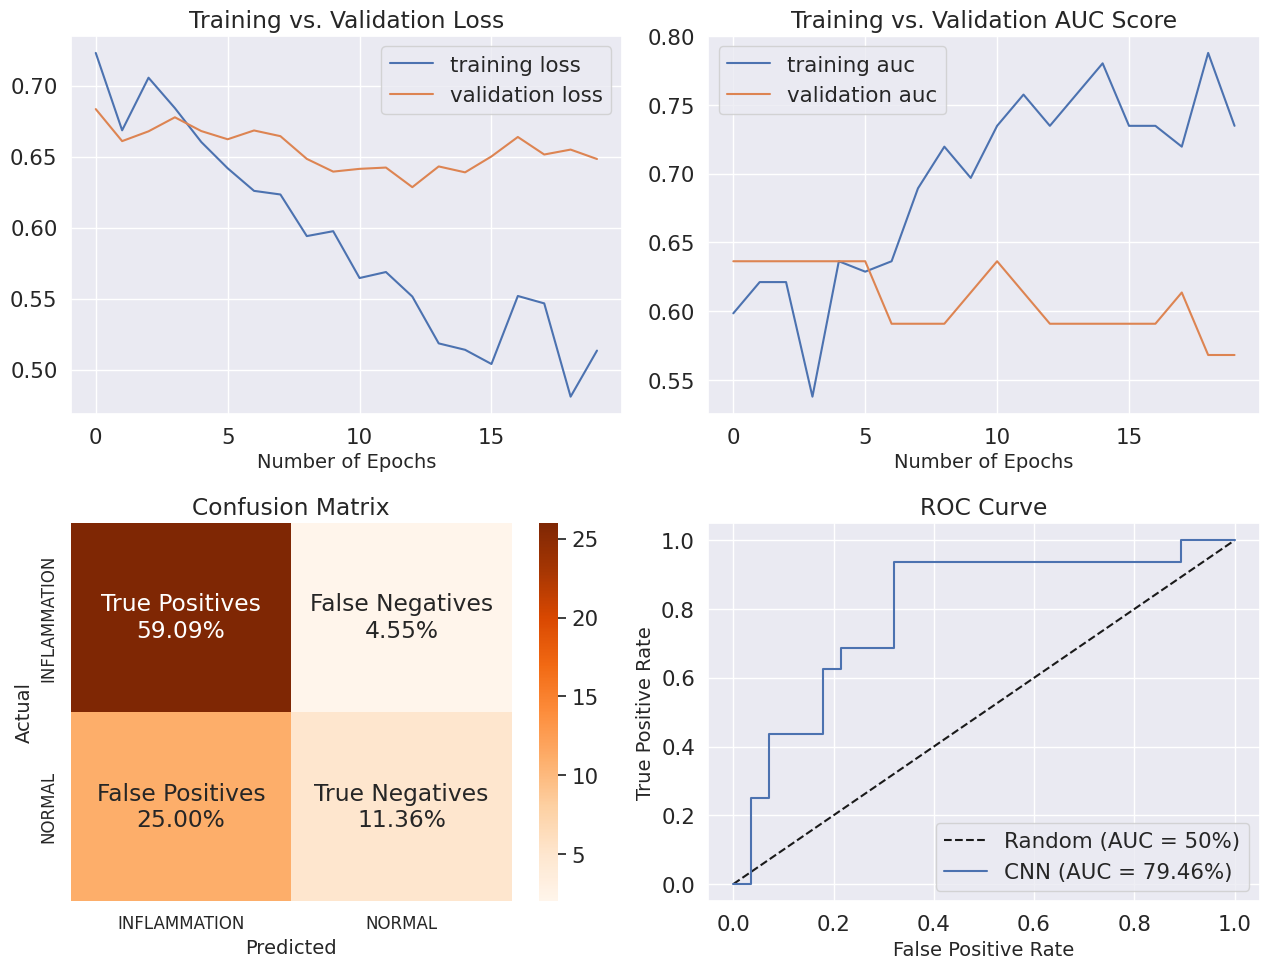

In [ ]:
create_charts(model, history)

In [ ]:
model.save('/model/cnn.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Load model yang telah disimpan
model = load_model('/model/cnn.h5')

# Fungsi untuk memprediksi gambar
def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
    img_tensor = tf.keras.preprocessing.image.img_to_array(img)  # Image data encoded as integers in the 0–255 range
    img_tensor /= 255.  # Normalize to [0,1] for plt.imshow application

    # Mengubah bentuk menjadi (1, 256, 256, 3)
    img_tensor = np.expand_dims(img_tensor, axis=0)

    # Prediksi gambar
    prediction = model.predict(img_tensor)
    return prediction

In [ ]:
data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/periodontal_disease/periodontal_disease')

Found 220 files belonging to 3 classes.


In [ ]:
data_iterator = data.as_numpy_iterator()

In [ ]:
batch = data_iterator.next()

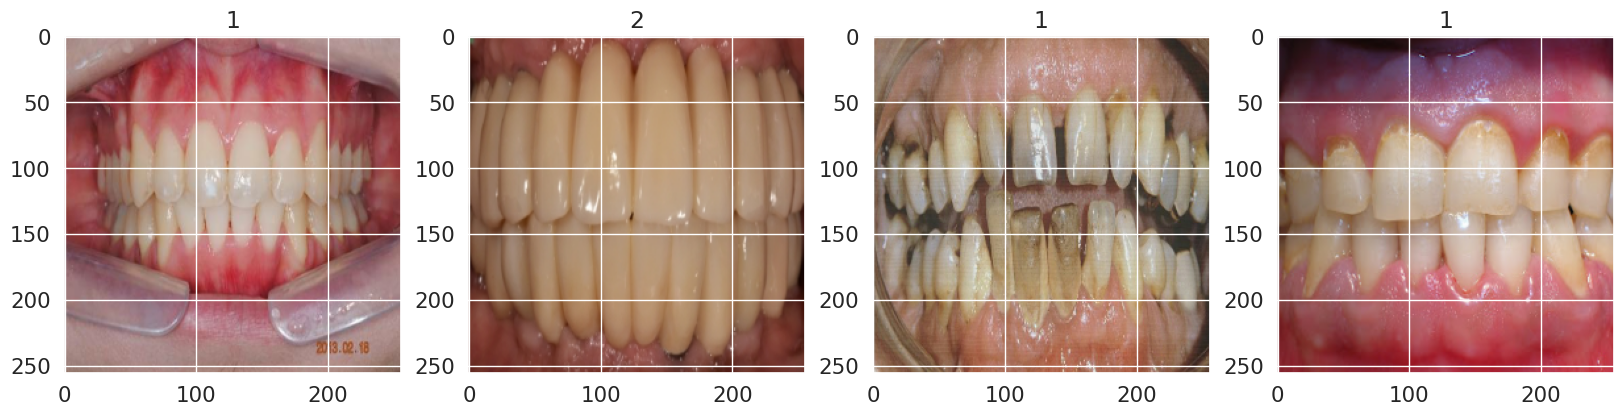

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

1/1 [==============================] - 0s 154ms/step


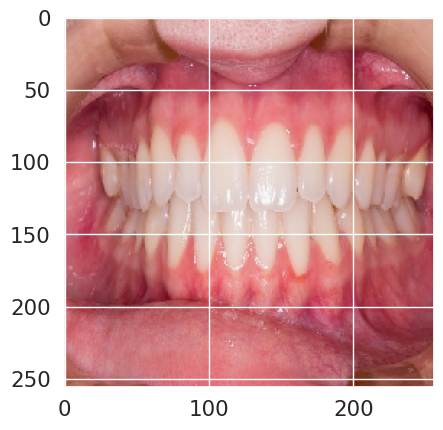

Gambar ini diprediksi sebagai 'NORMAL' dengan probabilitas 61.43%
1/1 [==============================] - 0s 58ms/step


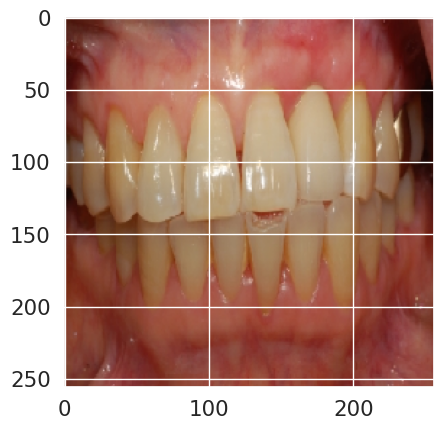

Gambar ini diprediksi sebagai 'INFLAMMATION' dengan probabilitas 62.67%
1/1 [==============================] - 0s 60ms/step


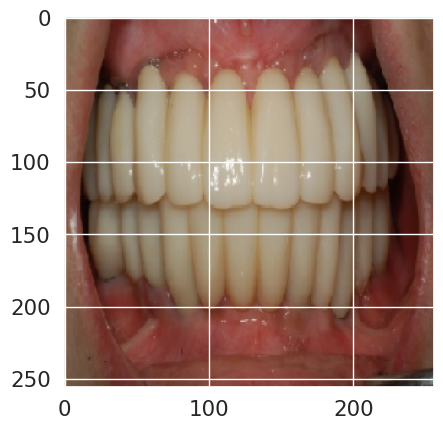

Gambar ini diprediksi sebagai 'INFLAMMATION' dengan probabilitas 62.59%
1/1 [==============================] - 0s 59ms/step


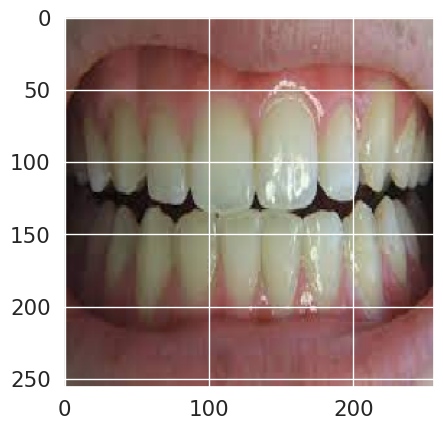

Gambar ini diprediksi sebagai 'NORMAL' dengan probabilitas 54.33%


In [ ]:
# List of test paths
test_paths = ['/content/drive/MyDrive/periodontal_disease/periodontal_disease/test/inflammation/n00000003_000197.jpg',
              '/content/drive/MyDrive/periodontal_disease/periodontal_disease/test/inflammation/n00000003_000163.jpg',
              '/content/drive/MyDrive/periodontal_disease/periodontal_disease/test/normal/n00000003_000190.jpg',
              '/content/drive/MyDrive/periodontal_disease/periodontal_disease/test/normal/n00000003_000198.jpg']

# Loop over each test path
for test_path in test_paths:
    # Prediksi gambar
    prediction = predict_image(test_path)

    # Tampilkan gambar
    img = tf.keras.preprocessing.image.load_img(test_path, target_size=(256, 256))
    plt.imshow(img)
    plt.show()

    # Tampilkan hasil prediksi
    if prediction < 0.5:
        print("Gambar ini diprediksi sebagai 'INFLAMMATION' dengan probabilitas {:.2%}".format(1 - prediction[0][0]))
    else:
        print("Gambar ini diprediksi sebagai 'NORMAL' dengan probabilitas {:.2%}".format(prediction[0][0]))